<div style="text-align:center; padding-top:60px;">

# Basic Concepts of Deep Learning
## Neurons · Networks · Training · Optimization

**From Biological Inspiration to Modern Neural Networks**

**MUSA 650 — Week 11**

---
⏱ 55 minutes &nbsp;|&nbsp; 5 parts &nbsp;|&nbsp; live code

</div>

## Context: Where We Are

| Week | Topics |
|------|--------|
| 8 | Neural networks basics, MLP, first CNNs on MNIST |
| 9 | CNN architecture deep-dive, image segmentation, U-Net |
| 10 | Making DL work in practice: augmentation, generators, regularization |
| **11** | **Deep dive: foundational concepts behind all of the above** |

---

**Why revisit the foundations now?**
- You've *used* neural networks — now we understand *why* they work
- Foundations help you debug, tune, and choose the right architecture
- Guest lecture case studies next week will make more sense with this grounding

## Today's Agenda

| # | Topic | Time |
|---|-------|------|
| 1 | What Is Deep Learning? Motivation & the Big Picture | ~8 min |
| 2 | The Building Block: Artificial Neuron | ~10 min |
| 3 | From Neurons to Networks: MLP & Activation Functions | ~10 min |
| 4 | Training: Forward Pass, Loss & Backpropagation | ~15 min |
| 5 | Optimizers, Hyperparameters & Practical Tips | ~8 min |
| — | Q&A / Bridge to Remote Sensing | ~4 min |

> **Goal**: Build a solid mental model of how neural networks learn — from a single neuron all the way to gradient descent.

# Part 1
## What Is Deep Learning?

## The Machine Learning Landscape

```
Artificial Intelligence
└── Machine Learning
    ├── Classical ML  (Random Forests, SVMs, k-NN)
    └── Deep Learning
        ├── Feedforward Networks (MLP)
        ├── Convolutional Networks (CNN)
        ├── Recurrent Networks (RNN, LSTM)
        └── Transformers (BERT, ViT, GPT)
```

### What makes it "deep"?

**Depth** = many layers of learned transformations stacked on top of each other.

| Approach | Feature engineering | # Layers |
|---|---|---|
| Classical ML | **Manual** (NDVI, texture, shape) | 1–2 |
| Shallow NN | Manual or learned | 2–3 |
| **Deep Learning** | **Learned automatically** | 10–1000+ |

> Deep learning learns *both* the features *and* the classifier from raw data.

## Why Deep Learning Works Now

The idea of multi-layer neural networks dates to the 1980s. Why did it take off around 2012?

| Ingredient | Status in 1990 | Status today |
|---|---|---|
| **Data** | Thousands of labeled examples | Millions–Billions |
| **Compute** | CPU only, slow | GPU / TPU — 1000× faster |
| **Algorithms** | Vanishing gradients, poor init | ReLU, BatchNorm, better optimizers |
| **Frameworks** | Hand-coded Fortran/C | Keras, PyTorch — automatic differentiation |

### The 2012 turning point: AlexNet

- ImageNet challenge: classify 1.2M images into 1000 categories
- AlexNet (deep CNN): **16.4% error** vs. 26.2% for the best non-DL method
- Trained on 2 GPUs for 5 days
- **This moment launched the modern deep learning era**

## Deep Learning for Remote Sensing

Why is deep learning especially powerful for satellite imagery?

| Challenge | Classical ML struggle | Deep Learning advantage |
|---|---|---|
| High-dimensional input | Manual feature extraction (NDVI, texture, etc.) | Learns features directly from pixels |
| Spatial structure | Treats pixels independently | Convolutional layers capture local patterns |
| Scale variation | Fixed-scale features | Pooling captures multi-scale patterns |
| Multi-spectral | Manual band combination | Learns optimal band combinations |

### Applications in MUSA 650
- Land cover classification (what is this pixel?)
- Semantic segmentation (label every pixel in an image)
- Change detection (what changed between two images?)
- Building / road footprint extraction

# Part 2
## The Building Block: The Artificial Neuron

## Biological Inspiration

The artificial neuron is loosely inspired by biological neurons:

```
Biological neuron:              Artificial neuron:

Dendrites (inputs)              x₁, x₂, x₃  (input features)
    ↓                                ↓
Cell body (summation)           weighted sum: Σ wᵢxᵢ + b
    ↓                                ↓
Axon hillock (threshold)        activation function f(·)
    ↓                                ↓
Axon (output signal)            output: ŷ = f(Σ wᵢxᵢ + b)
```

**Three components of a neuron:**
1. **Weights** (w): how much to trust each input
2. **Bias** (b): offset — allows the neuron to fire even when inputs are zero
3. **Activation function** f(·): introduces non-linearity

## The Perceptron: Simplest Neuron

Given inputs **x** = [x₁, x₂, ..., xₙ]:

$$z = w_1 x_1 + w_2 x_2 + \ldots + w_n x_n + b = \mathbf{w}^\top \mathbf{x} + b$$

$$\hat{y} = f(z)$$

For a **binary classifier**, f is a step function: output 1 if z > 0, else 0.

### Example: Is this a vegetation pixel?

| Input | Meaning | Weight |
|-------|---------|--------|
| x₁ = NIR reflectance | High in vegetation | w₁ = +0.8 |
| x₂ = Red reflectance | Low in vegetation | w₂ = −0.6 |
| x₃ = SWIR reflectance | Low in vegetation | w₃ = −0.3 |
| b = −0.1 | Bias | — |

z = 0.8·NIR − 0.6·Red − 0.3·SWIR − 0.1  
If z > 0 → vegetation; else → not vegetation

> This is essentially a **learned linear classifier** — similar to logistic regression.

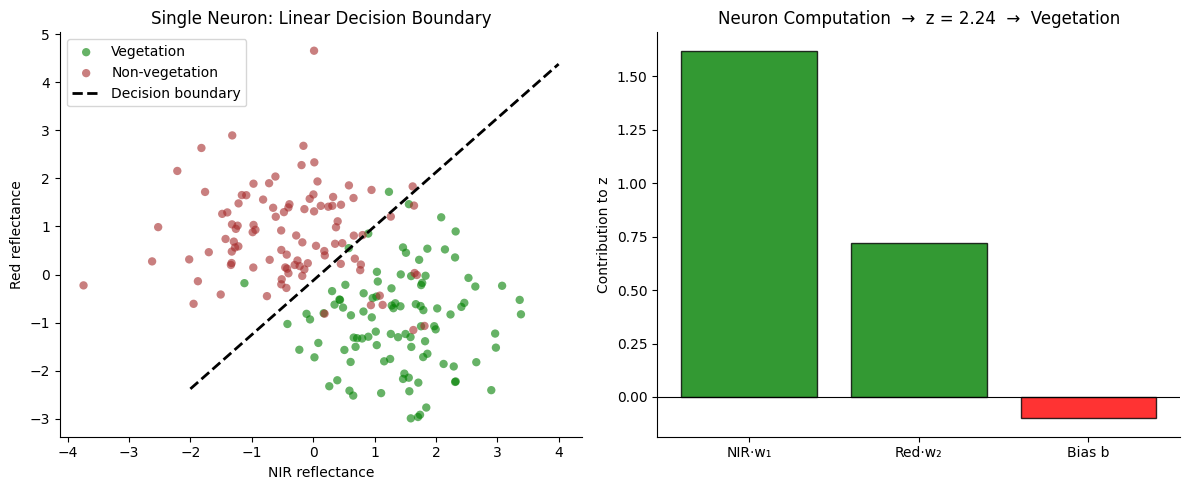

z = 1.62 + 0.72 + -0.10 = 2.24  → VEGETATION


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Visualise what a single neuron (perceptron) computes
np.random.seed(42)

# Simulate 200 pixels: [NIR, Red] — 2 features for visualisation
n = 200
# Vegetation pixels: high NIR, low Red
veg = np.random.randn(n // 2, 2) + np.array([1.5, -1.0])
# Non-vegetation: balanced or inverted
non_veg = np.random.randn(n // 2, 2) + np.array([-0.5, 0.8])

X = np.vstack([veg, non_veg])
y = np.array([1] * (n // 2) + [0] * (n // 2))

# Learned weights (after training)
w = np.array([0.9, -0.8])
b = -0.1

# Decision boundary: w[0]*x + w[1]*y + b = 0  =>  y = -(w[0]*x + b) / w[1]
x_line = np.linspace(-2, 4, 100)
y_line = -(w[0] * x_line + b) / w[1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: scatter
ax = axes[0]
ax.scatter(veg[:, 0],     veg[:, 1],     c='green',  alpha=0.6, label='Vegetation',     edgecolors='none')
ax.scatter(non_veg[:, 0], non_veg[:, 1], c='brown',  alpha=0.6, label='Non-vegetation', edgecolors='none')
ax.plot(x_line, y_line, 'k--', lw=2, label='Decision boundary')
ax.set_xlabel('NIR reflectance'); ax.set_ylabel('Red reflectance')
ax.set_title('Single Neuron: Linear Decision Boundary')
ax.legend(); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Right: neuron diagram as a weighted sum bar chart
ax2 = axes[1]
sample = np.array([1.8, -0.9])   # one vegetation pixel
contributions = w * sample
bars = ['NIR·w₁', 'Red·w₂', 'Bias b']
values = [contributions[0], contributions[1], b]
colors = ['green' if v > 0 else 'red' for v in values]
ax2.bar(bars, values, color=colors, alpha=0.8, edgecolor='black')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel('Contribution to z')
ax2.set_title(f'Neuron Computation  →  z = {sum(values):.2f}  →  Vegetation')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
print(f"z = {contributions[0]:.2f} + {contributions[1]:.2f} + {b:.2f} = {sum(values):.2f}  → {'VEGETATION' if sum(values) > 0 else 'NOT vegetation'}")

## The Limits of One Neuron

A single neuron can only learn a **linear** decision boundary.

### XOR problem — cannot be solved by one neuron:

```
Input A | Input B | Output
   0    |    0    |   0
   0    |    1    |   1
   1    |    0    |   1
   1    |    1    |   0
```

No single straight line can separate the 1s from the 0s.

### Real-world equivalent:

Land cover classification is **highly non-linear**:
- Urban areas and bare soil can have similar reflectance
- Flooded fields look like water
- Shadows look like dark vegetation

**Solution**: Stack neurons into layers → Multi-Layer Perceptron (MLP)

# Part 3
## From Neurons to Networks: MLP & Activation Functions

## The Multi-Layer Perceptron (MLP)

Stack neurons in **layers** — each layer's output becomes the next layer's input:

```
Input layer      Hidden layer 1    Hidden layer 2    Output layer

  x₁ ─────┐
  x₂ ────┐│──→  [neuron]  ─┐
  x₃ ───┐││──→  [neuron]   ├──→  [neuron] ─┐
  x₄ ──┐│││──→  [neuron]   │    [neuron]   ├──→  ŷ  (class probability)
  x₅ ─┐││││──→  [neuron]  ─┘    [neuron]  ─┘
       └┴┴┴┘
```

### Key vocabulary:

| Term | Meaning |
|------|----------|
| **Input layer** | Raw features (pixels, reflectance bands) |
| **Hidden layer** | Intermediate learned representations |
| **Output layer** | Final prediction (class scores, probabilities) |
| **Fully connected** | Every neuron connects to every neuron in the next layer |
| **Depth** | Number of hidden layers |
| **Width** | Number of neurons per layer |

> Each hidden layer learns increasingly **abstract** features.

## Why Non-Linearity Matters: Activation Functions

Without activation functions, stacking layers does **nothing**:

```
Layer 2 output = W₂ · (W₁ · x + b₁) + b₂
              = (W₂W₁) · x + (W₂b₁ + b₂)
              = W' · x + b'      ← still just a linear function!
```

**Activation functions introduce non-linearity** — allowing the network to learn complex patterns.

### The four most common activation functions:

| Function | Formula | Common use |
|---|---|---|
| **Sigmoid** | 1 / (1 + e⁻ᶻ) | Binary output (0–1) |
| **Tanh** | (eᶻ − e⁻ᶻ) / (eᶻ + e⁻ᶻ) | Hidden layers (centered) |
| **ReLU** | max(0, z) | Default for hidden layers |
| **Softmax** | eᶻᵢ / Σeᶻⱼ | Multi-class output |

> **ReLU** (Rectified Linear Unit) is the most widely used — simple, fast, avoids vanishing gradients.

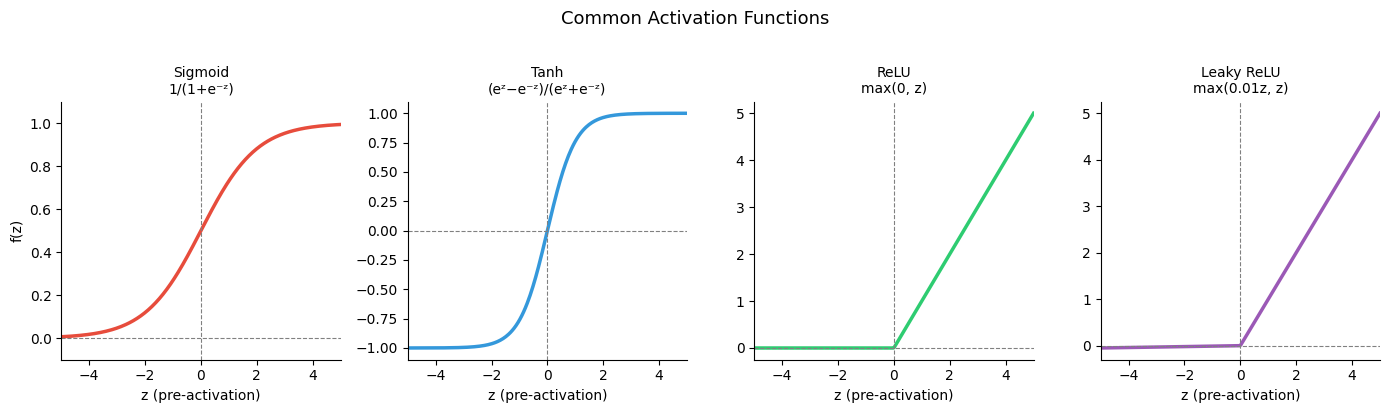

In [2]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-5, 5, 300)

activations = {
    'Sigmoid\n1/(1+e⁻ᶻ)': 1 / (1 + np.exp(-z)),
    'Tanh\n(eᶻ−e⁻ᶻ)/(eᶻ+e⁻ᶻ)': np.tanh(z),
    'ReLU\nmax(0, z)': np.maximum(0, z),
    'Leaky ReLU\nmax(0.01z, z)': np.where(z >= 0, z, 0.01 * z),
}

colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, (name, f), color in zip(axes, activations.items(), colors):
    ax.plot(z, f, color=color, lw=2.5)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.axvline(0, color='gray', lw=0.8, ls='--')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('z (pre-activation)')
    ax.set_xlim(-5, 5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('f(z)')
axes[0].set_ylim(-0.1, 1.1)
axes[1].set_ylim(-1.1, 1.1)

plt.suptitle('Common Activation Functions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Choosing Activation Functions

| Layer | Recommended | Why |
|-------|-------------|-----|
| Hidden layers | **ReLU** | Simple, fast, avoids vanishing gradient |
| Hidden layers (alternative) | **Leaky ReLU / ELU** | Avoids "dying ReLU" problem |
| Binary output | **Sigmoid** | Output is a probability in [0, 1] |
| Multi-class output | **Softmax** | Outputs sum to 1 — class probabilities |
| Regression output | **Linear (none)** | Unbounded output |

### The "dying ReLU" problem:
If a neuron's pre-activation z is always negative, ReLU always outputs 0 — the neuron is **dead**.

```
ReLU(z) = 0 when z < 0
Gradient = 0 when z < 0
→ Weight never updates → neuron permanently dead
```

**Fix**: Leaky ReLU — small negative slope (0.01) instead of zero.

## Universal Approximation Theorem

> A feedforward neural network with **at least one hidden layer** and a non-linear activation function can approximate **any continuous function** to arbitrary precision — given enough neurons.

### What this means in practice:

- One hidden layer is enough **in theory** — but impractical (needs exponentially many neurons)
- **Depth** is more parameter-efficient than width
- Adding layers = learning **hierarchical representations**

### Hierarchical features in satellite imagery:

```
Layer 1: Edges, gradients, color boundaries
Layer 2: Textures, simple shapes
Layer 3: Building corners, road segments, field boundaries
Layer 4: Complex structures (urban blocks, forest patches)
Output:  Land cover class
```

> Each layer builds on the previous, creating increasingly abstract and meaningful representations.

# Part 4
## Training: Forward Pass, Loss & Backpropagation

## The Training Loop: Big Picture

```
Training data (X, y)
       ↓
┌─────────────────────────────────────────┐
│  1. FORWARD PASS                        │
│     Input x → Network → Prediction ŷ   │
│                                         │
│  2. COMPUTE LOSS                        │
│     L = loss(ŷ, y)  ← how wrong are we?│
│                                         │
│  3. BACKWARD PASS (Backpropagation)     │
│     Compute ∂L/∂w for every weight w   │
│                                         │
│  4. UPDATE WEIGHTS                      │
│     w ← w − η · ∂L/∂w                  │
└─────────────────────────────────────────┘
       ↑                 |
       └─── Repeat (one epoch = one full pass through data) ───┘
```

- **η (eta)** = learning rate — how big a step to take
- Repeat for many epochs until loss stops improving

## Step 1: The Forward Pass

Data flows **forward** through the network, layer by layer:

```
Input x = [NIR, Red, Green, SWIR, ...]
   ↓
Layer 1:  h¹ = f(W¹x + b¹)     ← apply weights + bias + activation
   ↓
Layer 2:  h² = f(W²h¹ + b²)
   ↓
Output:   ŷ = softmax(W³h² + b³)  ← class probabilities
```

### Matrix form (one sample):

For each layer ℓ:
$$z^{(\ell)} = W^{(\ell)} h^{(\ell-1)} + b^{(\ell)}$$
$$h^{(\ell)} = f\left(z^{(\ell)}\right)$$

### For a batch of B samples: replace x (n,) with X (B, n) — matrix multiplication

This is why GPUs help so much — matrix multiplications are massively parallelizable.

## Step 2: The Loss Function

The loss function measures **how wrong the prediction is**. The goal of training is to minimize it.

### Common loss functions:

| Task | Loss function | Formula |
|------|--------------|----------|
| Binary classification | Binary cross-entropy | −[y log ŷ + (1−y) log(1−ŷ)] |
| Multi-class classification | Categorical cross-entropy | −Σ yᵢ log ŷᵢ |
| Regression | Mean Squared Error | (1/n) Σ (y − ŷ)² |
| Segmentation | Dice loss / IoU loss | 1 − 2|A∩B|/(|A|+|B|) |

### Intuition for cross-entropy:

```python
# True label: y = 1 (vegetation)
# Prediction A: ŷ = 0.95  →  loss = -log(0.95) = 0.05   (small, good!)
# Prediction B: ŷ = 0.30  →  loss = -log(0.30) = 1.20   (large, bad!)
# Prediction C: ŷ = 0.01  →  loss = -log(0.01) = 4.61   (terrible!)
```

> Loss is large when the model is **confident and wrong**. This is what we want to penalize most.

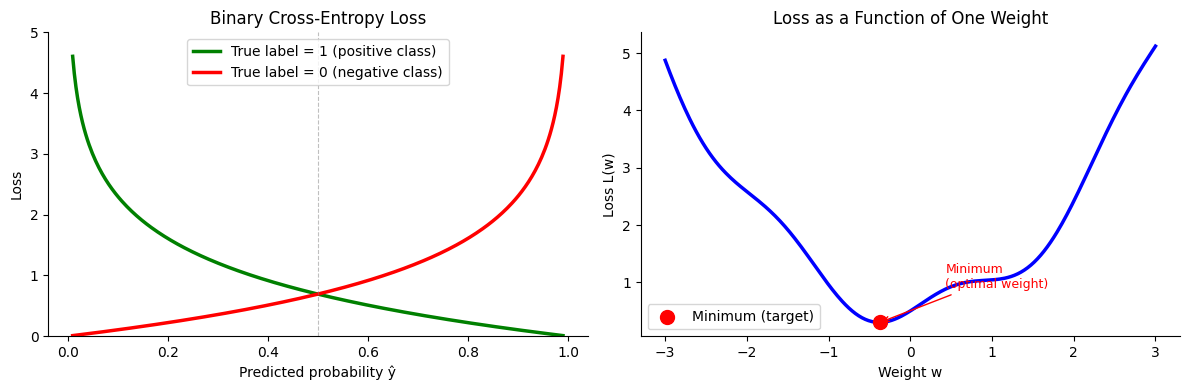

In [3]:
import numpy as np
import matplotlib.pyplot as plt

p = np.linspace(0.01, 0.99, 300)

# Binary cross-entropy for true label y=1: -log(p)
bce_pos = -np.log(p)
# Binary cross-entropy for true label y=0: -log(1-p)
bce_neg = -np.log(1 - p)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(p, bce_pos, 'g-', lw=2.5, label='True label = 1 (positive class)')
ax.plot(p, bce_neg, 'r-', lw=2.5, label='True label = 0 (negative class)')
ax.set_xlabel('Predicted probability ŷ')
ax.set_ylabel('Loss')
ax.set_title('Binary Cross-Entropy Loss')
ax.set_ylim(0, 5)
ax.legend()
ax.axvline(0.5, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Show loss landscape for a single parameter
ax2 = axes[1]
w = np.linspace(-3, 3, 300)
# Simulated loss curve: parabola-ish
loss = 0.5 * w**2 + 0.3 * np.sin(3 * w) + 0.5
ax2.plot(w, loss, 'b-', lw=2.5)
ax2.set_xlabel('Weight w')
ax2.set_ylabel('Loss L(w)')
ax2.set_title('Loss as a Function of One Weight')

# Mark the minimum
min_idx = np.argmin(loss)
ax2.scatter(w[min_idx], loss[min_idx], c='red', s=100, zorder=5, label='Minimum (target)')
ax2.annotate('Minimum\n(optimal weight)', xy=(w[min_idx], loss[min_idx]),
             xytext=(w[min_idx]+0.8, loss[min_idx]+0.6),
             arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)
ax2.legend()
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Step 3: Backpropagation

**Goal**: compute the gradient of the loss with respect to every weight in the network.

$$\frac{\partial L}{\partial w^{(\ell)}} = ?$$

### The Chain Rule (key insight):

If L depends on z, and z depends on w:
$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial z} \cdot \frac{\partial z}{\partial w}$$

**Backpropagation** applies the chain rule layer by layer, from the output back to the input:

```
Output layer:  compute ∂L/∂z³
    ↓
Layer 2:       compute ∂L/∂z² = (∂L/∂z³) · (∂z³/∂h²) · (∂h²/∂z²)
    ↓
Layer 1:       compute ∂L/∂z¹ = (∂L/∂z²) · (∂z²/∂h¹) · (∂h¹/∂z¹)
    ↓
Weights:       ∂L/∂W^(ℓ) = (∂L/∂z^(ℓ)) · h^(ℓ-1)
               ∂L/∂b^(ℓ) = ∂L/∂z^(ℓ)
```

> You **never need to implement backprop by hand** — Keras/PyTorch do automatic differentiation. But understanding it helps you debug and design networks.

## The Vanishing Gradient Problem

In deep networks, gradients can become **extremely small** as they propagate backward:

```
Sigmoid gradient at z=5: ≈ 0.007
Sigmoid gradient at z=10: ≈ 0.00005

10 layers × 0.007 per layer: 0.007^10 ≈ 2.8 × 10⁻²⁰  ← essentially zero!
```

**Early layers learn almost nothing** — their weights barely update.

### Solutions:

| Problem | Solution | How |
|---------|----------|-----|
| Vanishing gradient | **ReLU** activation | Gradient = 1 for z > 0 (doesn't shrink) |
| Vanishing gradient | **Residual connections** (ResNet) | Gradient flows directly through skip connections |
| Exploding gradient | **Gradient clipping** | Cap gradients at a max value |
| Both | **Batch Normalization** | Keeps activations in a healthy range |

> This is why **ReLU replaced sigmoid** as the default hidden layer activation around 2012.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-5, 5, 300)

# Sigmoid and its gradient
sigmoid = 1 / (1 + np.exp(-z))
sigmoid_grad = sigmoid * (1 - sigmoid)   # d/dz sigmoid(z)

# ReLU and its gradient
relu = np.maximum(0, z)
relu_grad = (z > 0).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (fn, grad, name, color) in zip(
    axes,
    [(sigmoid, sigmoid_grad, 'Sigmoid', '#e74c3c'),
     (relu, relu_grad, 'ReLU', '#2ecc71')]
):
    ax2 = ax.twinx()
    ax.plot(z, fn, color=color, lw=2.5, label=f'{name}')
    ax2.plot(z, grad, color=color, lw=2, ls='--', alpha=0.7, label=f'd/dz {name}')
    ax.set_xlabel('z')
    ax.set_ylabel(f'{name}(z)', color=color)
    ax2.set_ylabel(f'Gradient', color='gray')
    ax.set_title(f'{name}: Function and Gradient')

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    ax.spines['top'].set_visible(False)

# Annotate vanishing gradient
axes[0].annotate('Gradient ≈ 0\n(saturated region)',
                 xy=(4, sigmoid[z > 3.9][0]),
                 xytext=(2.5, 0.4),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 color='red', fontsize=9)

axes[1].annotate('Gradient = 1\n(constant, no vanishing!)',
                 xy=(2, relu[z > 1.9][0]),
                 xytext=(0, 3),
                 arrowprops=dict(arrowstyle='->', color='green'),
                 color='green', fontsize=9)

plt.suptitle('Vanishing Gradient: Sigmoid vs ReLU', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Part 5
## Optimizers, Hyperparameters & Practical Tips

## Gradient Descent: Finding the Minimum

After computing gradients, update weights by taking a step **downhill**:

$$w \leftarrow w - \eta \cdot \frac{\partial L}{\partial w}$$

where **η (eta)** is the learning rate.

### Three variants:

| Variant | Update using | Pro | Con |
|---------|-------------|-----|-----|
| **Batch GD** | Full training set | Stable updates | Very slow for large data |
| **Stochastic GD (SGD)** | One sample at a time | Fast updates | Noisy — high variance |
| **Mini-batch GD** | Small batch (32–256) | Balance of speed and stability | **Most common** |

**In practice**: Always use mini-batch gradient descent.

```python
model.fit(X_train, y_train, batch_size=32, epochs=50)
#                            ^^^^^^^^^^^
#                    Mini-batch size: 32 samples per update
```

## The Learning Rate: Most Important Hyperparameter

```
η too large:    overshoots minimum — loss oscillates or diverges
η too small:    converges very slowly — may get stuck
η just right:   smooth convergence to minimum
```

### Typical starting values:
- **Adam**: 0.001 (default)
- **SGD with momentum**: 0.01

### Learning rate schedules:

| Schedule | How it works | When to use |
|---|---|---|
| Constant | η stays fixed | Simple baseline |
| Step decay | Halve η every N epochs | Stable training |
| Cosine annealing | η follows cosine curve | Fine-tuning |
| ReduceLROnPlateau | Reduce η when val loss stalls | Adaptive |

```python
from tensorflow.keras.callbacks import ReduceLROnPlateau
callback = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
model.fit(..., callbacks=[callback])
```

## Modern Optimizers: Beyond Vanilla SGD

Modern optimizers adapt the learning rate **per parameter**:

| Optimizer | Key idea | Notes |
|-----------|----------|-------|
| **SGD** | Fixed η, fixed step | Simple; add momentum to reduce oscillation |
| **Momentum** | Uses moving average of past gradients | Faster on ravines |
| **RMSprop** | Divides η by running avg of squared grads | Good for RNNs |
| **Adam** | Combines momentum + RMSprop | **Default choice** for most tasks |
| **AdamW** | Adam + weight decay | Better generalization |

### Adam in Keras:

```python
model.compile(
    optimizer='adam',            # or tf.keras.optimizers.Adam(learning_rate=1e-3)
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
```

> **Rule of thumb**: Start with Adam + default learning rate. If results are poor, try SGD with momentum + learning rate schedule.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
epochs = np.arange(1, 51)

def sim_loss(decay, noise_scale, start=2.5):
    loss = start * np.exp(-decay * epochs) + 0.1
    loss += np.random.randn(len(epochs)) * noise_scale
    return np.clip(loss, 0.05, None)

scenarios = {
    'η too large (0.5)':   sim_loss(0.02, 0.4),
    'η too small (1e-5)':  sim_loss(0.01, 0.02) + 1.5,
    'η good (0.001, Adam)': sim_loss(0.08, 0.05),
}

colors = ['#e74c3c', '#3498db', '#2ecc71']
styles = ['--', ':', '-']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: learning rate comparison
ax = axes[0]
for (label, loss), color, style in zip(scenarios.items(), colors, styles):
    ax.plot(epochs, loss, color=color, lw=2, ls=style, label=label)
ax.set_xlabel('Epoch'); ax.set_ylabel('Training Loss')
ax.set_title('Effect of Learning Rate on Training')
ax.legend(fontsize=9); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Right: loss landscape with gradient descent steps
ax2 = axes[1]
w = np.linspace(-3, 3, 500)
loss_landscape = w**2 + 0.5 * np.sin(5 * w)   # bowl with bumps
ax2.plot(w, loss_landscape, 'b-', lw=2, alpha=0.7)

# Simulate gradient descent with good lr
w_curr = 2.5
lr = 0.15
path_w, path_l = [w_curr], [w_curr**2 + 0.5 * np.sin(5 * w_curr)]
for _ in range(12):
    grad = 2 * w_curr + 2.5 * np.cos(5 * w_curr)
    w_curr = w_curr - lr * grad
    path_w.append(w_curr)
    path_l.append(w_curr**2 + 0.5 * np.sin(5 * w_curr))

ax2.plot(path_w, path_l, 'ro-', ms=5, lw=1.5, label='Gradient descent steps')
ax2.set_xlabel('Weight w'); ax2.set_ylabel('Loss L(w)')
ax2.set_title('Gradient Descent on Loss Landscape')
ax2.legend(fontsize=9); ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Key Hyperparameters Summary

| Hyperparameter | Typical range | Effect |
|---|---|---|
| **Learning rate** | 1e-4 to 1e-1 | Speed and stability of training |
| **Batch size** | 16 – 256 | Memory, gradient noise, speed |
| **Epochs** | 10 – 200 | How long to train |
| **# layers** | 2 – 100+ | Model capacity |
| **# neurons/layer** | 32 – 2048 | Width = capacity |
| **Dropout rate** | 0.1 – 0.5 | Regularization |
| **Weight initialization** | Xavier / He | Starting point for gradient descent |

### A practical initialization strategy:

```python
# He initialization (good with ReLU)
Dense(128, activation='relu', kernel_initializer='he_normal')

# Glorot/Xavier initialization (good with tanh/sigmoid)
Dense(128, activation='tanh', kernel_initializer='glorot_uniform')
```

> Poor initialization can cause vanishing/exploding gradients *before training even begins*.

## Putting It All Together: A Complete Training Pipeline

```python
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Define the model
model = Sequential([
    Dense(256, input_shape=(n_features,), kernel_initializer='he_normal'),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Dropout(0.3),

    Dense(128, kernel_initializer='he_normal'),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Dropout(0.3),

    Dense(n_classes, activation='softmax')   # multi-class output
])

# 2. Compile: choose optimizer + loss + metric
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
]

# 4. Train
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=64, epochs=100,
    callbacks=callbacks
)
```

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate a realistic training run with early stopping
np.random.seed(7)
n_epochs = 60
epochs = np.arange(1, n_epochs + 1)

train_loss = 1.8 * np.exp(-0.07 * epochs) + 0.12 + np.random.randn(n_epochs) * 0.02
val_loss   = 1.8 * np.exp(-0.05 * epochs) + 0.28 + np.random.randn(n_epochs) * 0.03
# Val loss starts climbing after epoch ~35 (overfitting sets in)
val_loss[35:] += np.linspace(0, 0.3, n_epochs - 35) + np.random.randn(n_epochs - 35) * 0.03

train_acc = 1 - train_loss / 2
val_acc   = 1 - val_loss   / 2

best_epoch = np.argmin(val_loss) + 1   # early stopping point

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (tr, va, ylabel) in zip(axes, [
    (train_loss, val_loss, 'Loss'),
    (train_acc,  val_acc,  'Accuracy')
]):
    ax.plot(epochs, tr, 'b-', lw=2,   label='Training')
    ax.plot(epochs, va, 'r-', lw=2,   label='Validation')
    ax.axvline(best_epoch, color='green', lw=1.5, ls='--', label=f'Early stop (epoch {best_epoch})')
    ax.axvspan(best_epoch, n_epochs, alpha=0.07, color='red')
    ax.text(best_epoch + 1, ax.get_ylim()[0] + 0.02, 'Overfitting\nzone', color='red', fontsize=8)
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(f'Training {ylabel} Curve')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle('Complete Training Run — With Early Stopping', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
print(f"Best validation loss: {val_loss[best_epoch-1]:.4f} at epoch {best_epoch}")
print(f"Best validation accuracy: {val_acc[best_epoch-1]:.4f}")

## Connection to Remote Sensing: What Has Deep Learning Changed?

### Before deep learning (pre-2015):
- Manually compute spectral indices (NDVI, NDWI, EVI)
- Engineer texture features (GLCM, Gabor filters)
- Feed into Random Forest or SVM
- **Hours of domain expertise per dataset**

### With deep learning:
- Feed raw multi-spectral images into a CNN
- The network learns what features matter
- **Transfer learning**: pretrain on large datasets, fine-tune on your data
- State-of-the-art performance on land cover, segmentation, change detection

### What hasn't changed:
- Need for **labeled training data** (ground truth)
- Need for **careful validation** (geographic splits, not random)
- Risk of **overfitting to one region / sensor / season**
- Importance of **understanding what the model is actually doing**

> Deep learning is a powerful tool — not magic. Domain expertise still matters.

## Summary

| Concept | Key idea |
|---|---|
| **Artificial neuron** | Weighted sum + bias + activation function |
| **MLP** | Layers of neurons — learns hierarchical representations |
| **Activation functions** | ReLU for hidden layers; sigmoid/softmax for outputs |
| **Forward pass** | Input → layer-by-layer computation → prediction |
| **Loss function** | Measures how wrong the prediction is (cross-entropy for classification) |
| **Backpropagation** | Chain rule applied backward — computes gradients efficiently |
| **Gradient descent** | Update weights in the direction that reduces loss |
| **Learning rate** | Step size — most important hyperparameter |
| **Adam** | Default optimizer — adaptive per-parameter learning rates |
| **Early stopping** | Stop when validation loss stops improving |

### Key takeaways:
1. Deep learning = **learned feature extraction + classification**, end-to-end
2. Non-linearity (activation functions) is what makes depth powerful
3. Backpropagation + gradient descent = how networks learn from data
4. The learning rate is the single most important hyperparameter to tune
5. Always monitor **training vs. validation loss** to detect overfitting

---
**Next**: Guest lecture — deep learning applied to real remote sensing case studies